# Pipeline xử lý dữ liệu — Thống Nhất Bike

Notebook này thực hiện toàn bộ quy trình từ file zip thô → CSV phân tích.

Đầu vào:
- `data/raw/Database_6.zip` — SQL schema + dữ liệu lịch sử (2025-01 → 2026-02)
- `data/raw/Emails_Files_5.zip` — 1.132 email đặt hàng tháng 3/2026

Đầu ra (ghi vào `data/`):
- `fact_sales.csv` — bảng fact phẳng cho tất cả notebook phân tích
- `sales_order.csv`, `order_line.csv`, `email_log.csv`

In [1]:
import os, re, email, sqlite3, subprocess, zipfile
from email import policy
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR   = Path('../data')
RAW_DIR    = DATA_DIR / 'raw'
DB_PATH    = DATA_DIR / 'tnbike.db'
SQL_DIR    = RAW_DIR / 'sql'
EMAIL_DIR  = RAW_DIR / 'emails_mar2026'
RAR_DIR    = RAW_DIR / 'rar'

ZIP_DB     = RAW_DIR / 'Database_6.zip'
ZIP_EMAILS = RAW_DIR / 'Emails_Files_5.zip'

for d in [SQL_DIR, EMAIL_DIR, RAR_DIR]:
    os.makedirs(d, exist_ok=True)

assert ZIP_DB.exists(),     f'Thiếu file: {ZIP_DB}'
assert ZIP_EMAILS.exists(), f'Thiếu file: {ZIP_EMAILS}'
print('File zip đầu vào:')
print(f'  {ZIP_DB.name:30s} {ZIP_DB.stat().st_size/1024:.0f} KB')
print(f'  {ZIP_EMAILS.name:30s} {ZIP_EMAILS.stat().st_size/1024:.0f} KB')

File zip đầu vào:
  Database_6.zip                 199 KB
  Emails_Files_5.zip             8309 KB


## 1. Giải nén file sql từ Database_6.zip

In [2]:
with zipfile.ZipFile(ZIP_DB) as zf:
    print('Nội dung Database_6.zip:')
    for name in zf.namelist():
        print(f'  {name}')
    zf.extractall(SQL_DIR)

sql_data = (SQL_DIR / '02_import_data.sql').read_text(encoding='utf-8')
print(f'\n02_import_data.sql: {len(sql_data):,} ký tự')

Nội dung Database_6.zip:
  01_create_tables.sql
  02_import_data.sql
  Tnbike_Database_Schema_Doc.docx

02_import_data.sql: 2,668,599 ký tự


## 2. Tạo database SQLite

In [3]:
SCHEMA_SQL = '''
CREATE TABLE IF NOT EXISTS product_group (
    group_code TEXT PRIMARY KEY, group_name TEXT NOT NULL,
    description TEXT, created_at TEXT DEFAULT (datetime('now'))
);
CREATE TABLE IF NOT EXISTS product_line (
    line_id INTEGER PRIMARY KEY AUTOINCREMENT,
    line_name TEXT NOT NULL, group_code TEXT NOT NULL,
    created_at TEXT DEFAULT (datetime('now'))
);
CREATE TABLE IF NOT EXISTS product (
    product_code TEXT PRIMARY KEY, product_name TEXT, line_id INTEGER,
    color TEXT, unit TEXT DEFAULT 'Chiếc', is_active INTEGER DEFAULT 1,
    created_at TEXT DEFAULT (datetime('now'))
);
CREATE TABLE IF NOT EXISTS product_price (
    price_id INTEGER PRIMARY KEY AUTOINCREMENT,
    product_code TEXT NOT NULL, unit_price REAL NOT NULL,
    effective_from TEXT NOT NULL, effective_to TEXT,
    created_at TEXT DEFAULT (datetime('now'))
);
CREATE TABLE IF NOT EXISTS province (
    province_id INTEGER PRIMARY KEY AUTOINCREMENT,
    province_name TEXT NOT NULL UNIQUE, region TEXT,
    created_at TEXT DEFAULT (datetime('now'))
);
CREATE TABLE IF NOT EXISTS customer (
    customer_code TEXT PRIMARY KEY, customer_name TEXT NOT NULL,
    tax_code TEXT, address TEXT, province_id INTEGER,
    customer_tier TEXT DEFAULT 'STANDARD', is_active INTEGER DEFAULT 1,
    created_at TEXT DEFAULT (datetime('now')), updated_at TEXT DEFAULT (datetime('now'))
);
CREATE TABLE IF NOT EXISTS sales_order (
    order_id INTEGER PRIMARY KEY AUTOINCREMENT,
    so_number TEXT NOT NULL UNIQUE, invoice_symbol TEXT, invoice_number TEXT,
    order_date TEXT NOT NULL, customer_code TEXT NOT NULL,
    warehouse_code TEXT, payment_method TEXT, notes TEXT,
    total_amount REAL DEFAULT 0, total_quantity INTEGER DEFAULT 0,
    processing_status TEXT DEFAULT 'pending',
    created_at TEXT DEFAULT (datetime('now')), updated_at TEXT DEFAULT (datetime('now'))
);
CREATE TABLE IF NOT EXISTS order_line (
    line_id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_id INTEGER NOT NULL, so_number TEXT NOT NULL,
    product_code TEXT NOT NULL, quantity REAL NOT NULL,
    unit_price REAL NOT NULL, line_total REAL NOT NULL,
    created_at TEXT DEFAULT (datetime('now'))
);
CREATE TABLE IF NOT EXISTS fact_sales (
    fact_id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_date TEXT NOT NULL, fiscal_year INTEGER, fiscal_quarter INTEGER,
    fiscal_month INTEGER, week_of_year INTEGER,
    so_number TEXT NOT NULL, order_id INTEGER NOT NULL, line_id INTEGER NOT NULL,
    customer_code TEXT NOT NULL, customer_name TEXT,
    province_id INTEGER, province_name TEXT, region TEXT,
    product_code TEXT NOT NULL, product_name TEXT, color TEXT,
    line_id_fk INTEGER, line_name TEXT, group_code TEXT, group_name TEXT,
    quantity REAL NOT NULL, unit_price REAL NOT NULL, line_total REAL NOT NULL
);
CREATE TABLE IF NOT EXISTS email_log (
    log_id INTEGER PRIMARY KEY AUTOINCREMENT,
    message_id TEXT, from_address TEXT, received_at TEXT,
    attachment_name TEXT, processing_status TEXT DEFAULT 'processed',
    created_at TEXT DEFAULT (datetime('now'))
);
'''

if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(DB_PATH)
for stmt in SCHEMA_SQL.strip().split(';'):
    s = stmt.strip()
    if s:
        conn.execute(s)
conn.commit()

tbls = conn.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name").fetchall()
print(f'Database tạo xong — {len(tbls)} bảng:')
for t in tbls:
    print(f'  {t[0]}')

Database tạo xong — 11 bảng:
  customer
  email_log
  fact_sales
  order_line
  product
  product_group
  product_line
  product_price
  province
  sales_order
  sqlite_sequence


## 3. Import dữ liệu lịch sử (2025-01 → 2026-02)

In [4]:
def split_sql(text):
    """Tách SQL statements, tôn trọng semicolons bên trong string literals."""
    stmts, buf, in_str, i = [], [], False, 0
    while i < len(text):
        c = text[i]
        if c == "'" and not in_str:
            in_str = True
            buf.append(c)
        elif c == "'" and in_str:
            if i + 1 < len(text) and text[i + 1] == "'":
                buf.append("''")
                i += 2
                continue
            in_str = False
            buf.append(c)
        elif c == ';' and not in_str:
            s = ''.join(buf).strip()
            if s:
                stmts.append(s)
            buf = []
        else:
            buf.append(c)
        i += 1
    rem = ''.join(buf).strip()
    if rem:
        stmts.append(rem)
    return stmts


def prep_sql(text):
    text = re.sub(r'--[^\n]*', '', text)
    text = re.sub(r'SET\s+search_path[^;\n]*;?', '', text)
    text = re.sub(r'SET\s+client_encoding[^;\n]*;?', '', text)
    text = re.sub(r'INSERT INTO tnbike\.', 'INSERT INTO ', text)
    text = re.sub(r'\bTRUE\b', '1', text)
    text = re.sub(r'\bFALSE\b', '0', text)
    text = re.sub(r"NOW\(\)", "datetime('now')", text)
    text = re.sub(r'BEGIN\s*;', '', text)
    text = re.sub(r'COMMIT\s*;', '', text)
    return text


ok = err = skip = 0
for stmt in split_sql(prep_sql(sql_data)):
    if not stmt:
        continue
    if 'INSERT INTO fact_sales' in stmt or stmt.strip().upper().startswith('SELECT'):
        skip += 1
        continue
    try:
        conn.execute(stmt)
        ok += 1
    except Exception as e:
        err += 1
        print(f'Lỗi: {stmt[:60]} -> {e}')
conn.commit()
print(f'Import xong — ok={ok}, lỗi={err}, bỏ qua={skip}')
print()
for t in ['product_group','product_line','product','province','customer','sales_order','order_line']:
    n = conn.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
    print(f'  {t:20s}: {n:,} rows')

Import xong — ok=8, lỗi=0, bỏ qua=2

  product_group       : 5 rows
  product_line        : 77 rows
  product             : 247 rows
  province            : 75 rows
  customer            : 702 rows
  sales_order         : 1,627 rows
  order_line          : 17,031 rows


## 4. Giải nén email tháng 3/2026

In [5]:
with zipfile.ZipFile(ZIP_EMAILS) as zf:
    print('Nội dung Emails_Files_5.zip:')
    for name in zf.namelist():
        print(f'  {name}')
    zf.extractall(RAR_DIR)

rar_emails = RAR_DIR / 'tnbike_emails_mar2026.rar'
eml_existing = [f for f in os.listdir(EMAIL_DIR) if f.endswith('.eml')]

if len(eml_existing) == 0:
    result = subprocess.run(
        ['unrar', 'x', '-y', str(rar_emails), str(EMAIL_DIR) + '/'],
        capture_output=True
    )
    if result.returncode != 0:
        raise RuntimeError('Lỗi unrar — kiểm tra unrar-free đã cài chưa')

n_eml = len([f for f in os.listdir(EMAIL_DIR) if f.endswith('.eml')])
print(f'Giải nén xong: {n_eml:,} file .eml')

Nội dung Emails_Files_5.zip:
  tnbike_emails_mar2026.rar
  tnbike_pdfs_mar2026.rar
Giải nén xong: 1,132 file .eml


## 5. Parse email → DataFrame

In [6]:
def parse_eml(fpath):
    with open(fpath, 'rb') as f:
        msg = email.message_from_bytes(f.read(), policy=policy.default)
    body = ''
    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() == 'text/plain':
                body = part.get_content()
                break
    else:
        body = msg.get_content()

    m_so  = re.search(r'BH26\.(\d+)', body)
    m_kh  = (re.search(r'\u0110\u1ea1i l\xfd\s*:\s*(.+)', body) or
              re.search(r'Kh\xe1ch h\xe0ng\s*:\s*(.+)', body) or
              re.search(r'T\xean\s*:\s*(.+)', body))
    m_date = (re.search(r'ng\xe0y\s+(\d{2}/\d{2}/\d{4})', body) or
               re.search(r'Ng\xe0y\s+\u0111\u1eb7t\s*:\s*(\d{2}/\d{2}/\d{4})', body))
    m_qty  = (re.search(r't\u1ed5ng\s+(\d+)\s+chi\u1ebfc', body, re.I) or
               re.search(r'T\u1ed5ng\s+s\u1ed1\s+l\u01b0\u1ee3ng\s*:\s*(\d+)', body) or
               re.search(r'(\d+)\s+chi\u1ebfc,', body))
    m_val  = (re.search(r'tr\u1ecb\s+gi\xe1\s+([\d\.]+)\s+\u0111\u1ed3ng', body, re.I) or
               re.search(r'T\u1ed5ng\s+gi\xe1\s+tr\u1ecb\s*:\s+([\d\.]+)\s+\u0111\u1ed3ng', body) or
               re.search(r't\u1ed5ng\s+gi\xe1\s+tr\u1ecb\s+([\d\.]+)\s+VN\u0110', body, re.I))

    if not (m_so and m_val):
        return None

    tri_gia    = float(m_val.group(1).replace('.', ''))
    order_date = '2026-03-01'
    if m_date:
        d, mo, y = m_date.group(1).split('/')
        order_date = f'{y}-{mo}-{d}'

    return {
        'file'         : os.path.basename(fpath),
        'so_number'    : f"BH26.{m_so.group(1)}",
        'customer_name': m_kh.group(1).strip() if m_kh else None,
        'order_date'   : order_date,
        'so_chiec'     : int(m_qty.group(1)) if m_qty else 1,
        'tri_gia'      : tri_gia,
    }


eml_files = sorted(Path(EMAIL_DIR).glob('*.eml'))
records, missed = [], []
for fp in eml_files:
    r = parse_eml(str(fp))
    if r:
        records.append(r)
    else:
        missed.append(fp.name)

df_email = pd.DataFrame(records)
print(f'Parse: {len(records):,} thành công | {len(missed)} bỏ qua')
if missed:
    print('Bỏ qua:', missed[:5])
print()
print(f"Tổng trị giá: {df_email['tri_gia'].sum()/1e9:.3f} tỷ VND")
print(f"Đơn hàng    : {df_email['so_number'].nunique():,}")
print(f"Khoảng ngày : {df_email['order_date'].min()} → {df_email['order_date'].max()}")
print()
print(df_email[['so_number','customer_name','order_date','so_chiec','tri_gia']].head(5).to_string())

Parse: 1,132 thành công | 0 bỏ qua

Tổng trị giá: 40.804 tỷ VND
Đơn hàng    : 1,132
Khoảng ngày : 2026-03-01 → 2026-03-31

   so_number                     customer_name  order_date  so_chiec     tri_gia
0  BH26.0935  CÔNG TY TNHH THƯƠNG MẠI LONG PHÚ  2026-03-01         1   1898148.0
1  BH26.0936  CÔNG TY TNHH THƯƠNG MẠI LONG PHÚ  2026-03-01         1   2861111.0
2  BH26.0937  CÔNG TY TNHH THƯƠNG MẠI LONG PHÚ  2026-03-01         1   1935185.0
3  BH26.0938          CÔNG TY CỔ PHẦN NAM TIẾN  2026-03-01         1   2953704.0
4  BH26.0939         DOANH NGHIỆP TW KHẢI HOÀN  2026-03-01        55  78111272.0


## 6. Chèn dữ liệu tháng 3/2026 vào database

In [7]:
cur = conn.cursor()

# Thêm customer và product placeholder cho đơn email không map được
cur.execute("""
    INSERT OR IGNORE INTO customer (customer_code, customer_name, customer_tier)
    VALUES ('KH-UNKNOWN', 'Khách hàng không xác định', 'STANDARD')
""")

# Thêm sản phẩm UNKNOWN đại diện cho đơn từ email (không có SKU chi tiết)
cur.execute("""
    INSERT OR IGNORE INTO product (product_code, product_name, unit)
    VALUES ('UNKNOWN', 'Sản phẩm chưa xác định (từ email)', 'Chiếc')
""")

# Map customer_name → customer_code
cur.execute('SELECT customer_code, customer_name FROM customer')
cust_map = {name.upper().strip(): code for code, name in cur.fetchall()}

max_oid = cur.execute('SELECT COALESCE(MAX(order_id),0) FROM sales_order').fetchone()[0]

insert_so = map_ok = map_miss = 0
new_oid = max_oid
for _, row in df_email.iterrows():
    cust_code = cust_map.get(str(row['customer_name']).upper().strip(), 'KH-UNKNOWN')
    if cust_code != 'KH-UNKNOWN':
        map_ok += 1
    else:
        map_miss += 1
    new_oid += 1
    cur.execute("""
        INSERT OR IGNORE INTO sales_order
        (order_id, so_number, invoice_symbol, invoice_number, order_date,
         customer_code, total_amount, total_quantity, processing_status)
        VALUES (?,?,'C26TTN',NULL,?,?,?,?,'processed')
    """, (new_oid, row['so_number'], row['order_date'], cust_code,
           float(row['tri_gia']), int(row['so_chiec'])))
    insert_so += cur.rowcount

# order_line: 1 dòng/đơn, product_code = UNKNOWN
max_lid = cur.execute('SELECT COALESCE(MAX(line_id),0) FROM order_line').fetchone()[0]
cur.execute("""
    SELECT order_id, so_number, total_amount, total_quantity
    FROM sales_order WHERE invoice_symbol='C26TTN' AND order_date LIKE '2026-03%'
""")
insert_ol = 0
new_lid = max_lid
for oid, so_num, tot_amt, tot_qty in cur.fetchall():
    qty = int(tot_qty) if tot_qty and tot_qty > 0 else 1
    up  = round(float(tot_amt) / qty, 2)
    new_lid += 1
    conn.execute("""
        INSERT OR IGNORE INTO order_line
        (line_id, order_id, so_number, product_code, quantity, unit_price, line_total)
        VALUES (?,?,?,'UNKNOWN',?,?,?)
    """, (new_lid, oid, so_num, qty, up, float(tot_amt)))
    insert_ol += 1

conn.commit()
print(f'Chèn xong: {insert_so:,} đơn hàng | {insert_ol:,} order lines')
print(f'Map customer: {map_ok:,} khớp | {map_miss:,} không khớp (KH-UNKNOWN)')

Chèn xong: 1,132 đơn hàng | 1,132 order lines
Map customer: 1,128 khớp | 4 không khớp (KH-UNKNOWN)


In [8]:
log_rows = [
    (row['so_number'], 'dathang@email.vn', row['order_date'],
     row['file'], 'processed')
    for _, row in df_email.iterrows()
]
conn.executemany("""
    INSERT OR IGNORE INTO email_log
    (message_id, from_address, received_at, attachment_name, processing_status)
    VALUES (?,?,?,?,?)
""", log_rows)
conn.commit()
n_log = conn.execute('SELECT COUNT(*) FROM email_log').fetchone()[0]
print(f'Email log: {n_log:,} records')

Email log: 1,132 records


## 7. Xây dựng lại fact_sales với đầy đủ thông tin dimension

In [9]:
conn.execute('DELETE FROM fact_sales')

conn.execute("""
INSERT INTO fact_sales (
    order_date, fiscal_year, fiscal_quarter, fiscal_month, week_of_year,
    so_number, order_id, line_id,
    customer_code, customer_name, province_id, province_name, region,
    product_code, product_name, color, line_id_fk, line_name, group_code, group_name,
    quantity, unit_price, line_total
)
SELECT
    so.order_date,
    CAST(strftime('%Y', so.order_date) AS INTEGER),
    CASE WHEN CAST(strftime('%m',so.order_date) AS INTEGER) BETWEEN 1 AND 3 THEN 1
         WHEN CAST(strftime('%m',so.order_date) AS INTEGER) BETWEEN 4 AND 6 THEN 2
         WHEN CAST(strftime('%m',so.order_date) AS INTEGER) BETWEEN 7 AND 9 THEN 3
         ELSE 4 END,
    CAST(strftime('%m', so.order_date) AS INTEGER),
    CAST(strftime('%W', so.order_date) AS INTEGER),
    ol.so_number, so.order_id, ol.line_id,
    c.customer_code, c.customer_name, c.province_id, pr.province_name, pr.region,
    p.product_code, p.product_name, p.color, p.line_id,
    pl.line_name, pg.group_code, pg.group_name,
    ol.quantity, ol.unit_price, ol.line_total
FROM order_line ol
JOIN sales_order  so ON so.order_id      = ol.order_id
JOIN customer     c  ON c.customer_code  = so.customer_code
JOIN product      p  ON p.product_code   = ol.product_code
LEFT JOIN product_line  pl ON pl.line_id    = p.line_id
LEFT JOIN product_group pg ON pg.group_code = pl.group_code
LEFT JOIN province      pr ON pr.province_id = c.province_id
""")
conn.commit()

n = conn.execute('SELECT COUNT(*) FROM fact_sales').fetchone()[0]
print(f'fact_sales rebuilt: {n:,} rows')
print()
rows = conn.execute("""
    SELECT strftime('%Y-%m', order_date) AS ym,
           COUNT(*) AS n, ROUND(SUM(line_total)/1e9,2) AS rev
    FROM fact_sales GROUP BY ym ORDER BY ym
""").fetchall()
print(f"{'Tháng':>8}  {'Rows':>7}  {'Doanh thu (tỷ)':>15}")
for ym, n_r, rev in rows:
    print(f'{ym:>8}  {n_r:>7,}  {rev:>15.2f}')
print()
# Kiểm tra cột dimension được fill đúng
sample = conn.execute("""
    SELECT product_code, product_name, color, line_name, group_name
    FROM fact_sales WHERE product_name IS NOT NULL LIMIT 3
""").fetchall()
print('Mẫu dimension:')
for r in sample:
    print(' ', r)

fact_sales rebuilt: 18,163 rows

   Tháng     Rows   Doanh thu (tỷ)
 2025-01      339             3.20
 2025-02    1,892             6.34
 2025-03    5,184            18.58
 2026-01    4,778            21.14
 2026-02    4,838            19.39
 2026-03    1,132            40.80

Mẫu dimension:
  ('000214004000000', 'Xe đạp Thống Nhất GN 05-26', '05-26', 'Xe GN 05-26', 'Xe phổ thông')
  ('000333002022000', 'Xe đạp Thống Nhất Super 26 xanh', 'xanh', 'Xe Super 26', 'Xe thể thao thép')
  ('000224002004000', 'Xe đạp Thống Nhất New 24 Đỏ tươi', 'Đỏ tươi', 'Xe New 24', 'Xe phổ thông')


## 8. Kiểm tra chất lượng dữ liệu

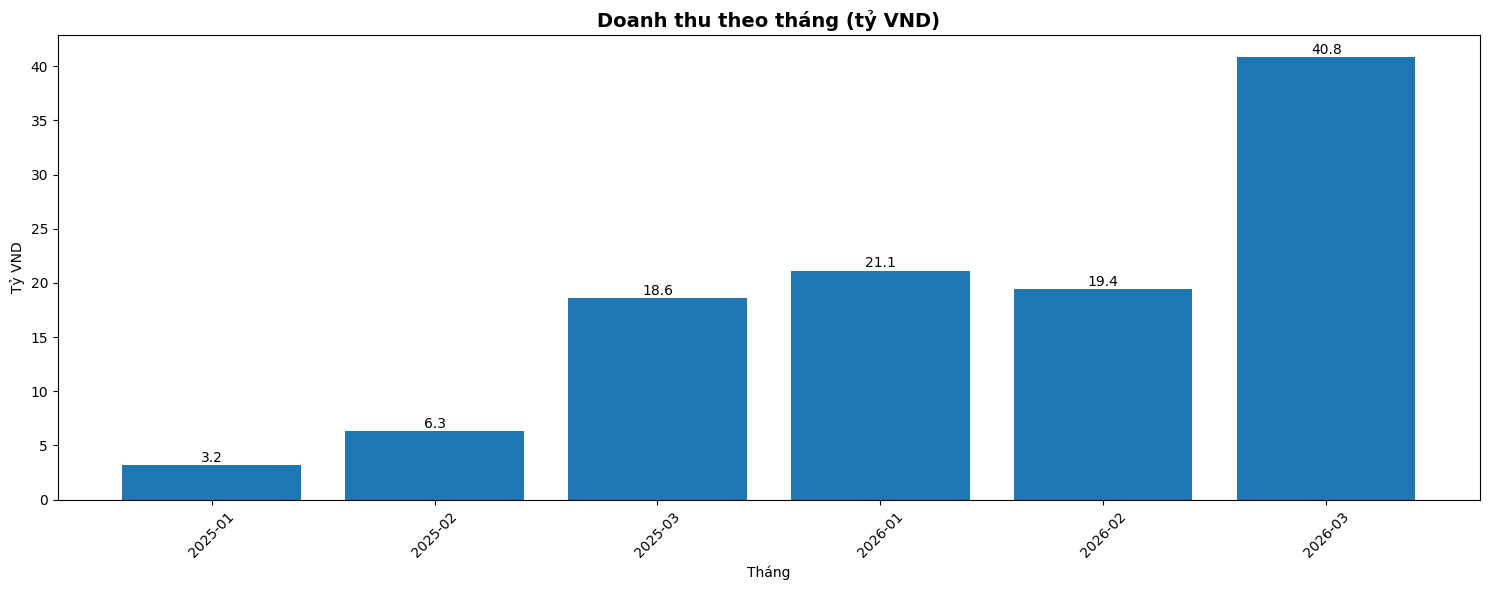

In [10]:
df_fs = pd.read_sql('SELECT * FROM fact_sales', conn)
df_fs['order_date'] = pd.to_datetime(df_fs['order_date'])
df_fs['ym'] = df_fs['order_date'].dt.to_period('M')

monthly = df_fs.groupby('ym')['line_total'].sum().reset_index()
monthly['rev_ty'] = monthly['line_total'] / 1e9
monthly['period'] = monthly['ym'].astype(str)

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(monthly['period'], monthly['rev_ty'])
ax.set_title('Doanh thu theo tháng (tỷ VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Tỷ VND')
ax.tick_params(axis='x', rotation=45)
for i, (_, r) in enumerate(monthly.iterrows()):
    ax.text(i, r['rev_ty'] + 0.3, f"{r['rev_ty']:.1f}", ha='center', fontsize=10)
fig.tight_layout()
plt.show()

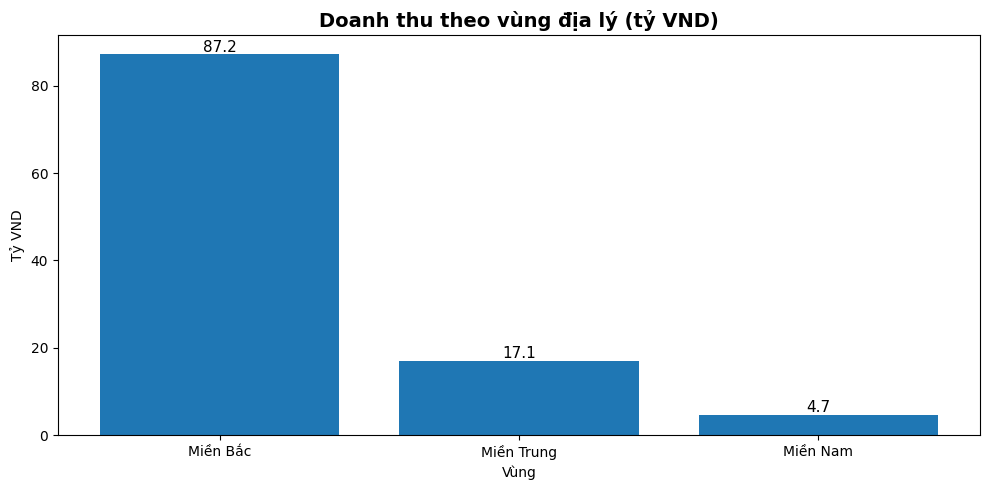

In [11]:
region_rev = (df_fs[df_fs['region'].notna()]
               .groupby('region')['line_total'].sum()
               .sort_values(ascending=False))
region_ty = region_rev / 1e9

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(region_ty.index, region_ty.values)
ax.set_title('Doanh thu theo vùng địa lý (tỷ VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Vùng')
ax.set_ylabel('Tỷ VND')
for i, v in enumerate(region_ty.values):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=11)
fig.tight_layout()
plt.show()

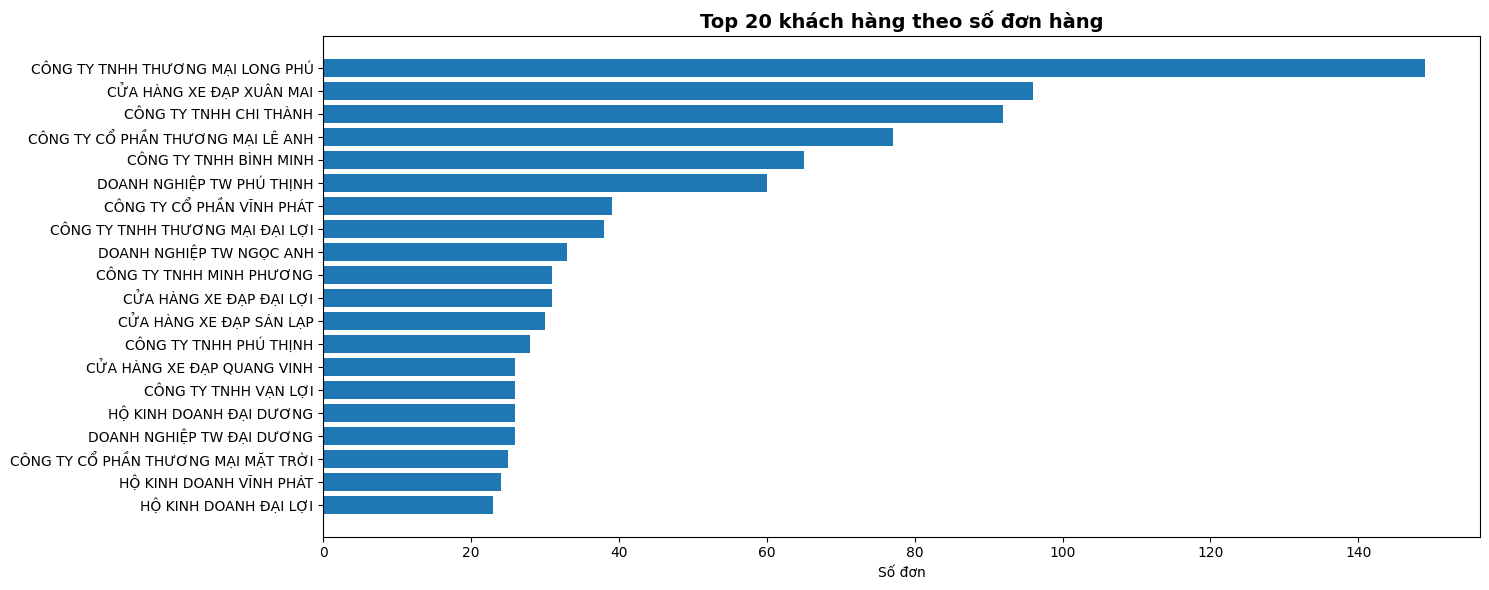

In [12]:
cust_ord = (df_fs.groupby('customer_name')['so_number']
             .nunique().sort_values(ascending=False).head(20))

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(cust_ord.index[::-1], cust_ord.values[::-1])
ax.set_title('Top 20 khách hàng theo số đơn hàng', fontsize=14, fontweight='bold')
ax.set_xlabel('Số đơn')
fig.tight_layout()
plt.show()

## 9. Xuất dữ liệu ra CSV

In [13]:
tables_export = {
    'fact_sales'  : 'SELECT * FROM fact_sales  ORDER BY order_date, so_number',
    'sales_order' : 'SELECT * FROM sales_order ORDER BY order_date, so_number',
    'order_line'  : 'SELECT * FROM order_line  ORDER BY line_id',
    'email_log'   : 'SELECT * FROM email_log   ORDER BY log_id',
}

for name, query in tables_export.items():
    df_out = pd.read_sql(query, conn)
    out_path = DATA_DIR / f'{name}.csv'
    df_out.to_csv(out_path, index=False, encoding='utf-8')
    print(f'  {name}.csv — {len(df_out):,} rows → {out_path}')

conn.close()
print()
print('Hoàn tất.')

  fact_sales.csv — 18,163 rows → ../data/fact_sales.csv
  sales_order.csv — 2,759 rows → ../data/sales_order.csv
  order_line.csv — 18,163 rows → ../data/order_line.csv
  email_log.csv — 1,132 rows → ../data/email_log.csv

Hoàn tất.


## Kết luận

Pipeline chạy theo 4 bước:

**Bước 1** — Giải nén `Database_6.zip` → đọc schema SQL và dữ liệu lịch sử (2025-01 đến 2026-02). Dữ liệu gồm 5 nhóm sản phẩm, 77 dòng sản phẩm, 247 SKU, 75 tỉnh/thành, 702 khách hàng.

**Bước 2** — Tạo SQLite với schema thuần SQLite (không dùng parser PostgreSQL để tránh lỗi). Hàm `split_sql()` tách statement theo `;` nằm ngoài string literal, giải quyết trường hợp dữ liệu địa chỉ chứa `;`.

**Bước 3** — Giải nén `Emails_Files_5.zip` → RAR → 1.132 file `.eml`, parse 3 định dạng email để lấy số đơn, khách hàng, ngày, số lượng và trị giá. Tổng 40,8 tỷ VND cho tháng 3/2026.

**Bước 4** — Chèn dữ liệu tháng 3/2026, rebuild `fact_sales` với JOIN đầy đủ (product_name, color, line_name, group_code từ bảng master), xuất 4 file CSV.

Lưu ý: đơn từ email dùng `product_code = 'UNKNOWN'` — email chỉ có tổng trị giá và số lượng, không có chi tiết SKU.